In [2]:
import h5py
import os
os.getcwd()


'/scratch/ty296'

In [ ]:
# Save plot data to CSV
output_filename = 'variance_vs_p_data.csv'
df_to_save = df[['variance', 'standard_error_of_variance']].copy()
df_to_save.to_csv(output_filename)
print(f"Data saved to {output_filename}")


In [2]:
import os

# List all files in the directory "hdf5_data/p_ctrl0.4_haining/"
dir_path = "hdf5_data/p_ctrl0.4_haining/"
files = os.listdir(dir_path)
files_full_path = [os.path.join(dir_path, f) for f in files]


In [3]:
files

['MPS_L24_pctrl0.400_pproj0.520_s529.h5',
 'MPS_L16_pctrl0.400_pproj0.796_s416.h5',
 'MPS_L16_pctrl0.400_pproj0.602_s1909.h5',
 'MPS_L24_pctrl0.400_pproj0.765_s856.h5',
 'MPS_L24_pctrl0.400_pproj0.633_s1955.h5',
 'MPS_L16_pctrl0.400_pproj0.796_s698.h5',
 'MPS_L16_pctrl0.400_pproj0.531_s415.h5',
 'MPS_L20_pctrl0.400_pproj0.684_s529.h5',
 'MPS_L24_pctrl0.400_pproj0.714_s29.h5',
 'MPS_L24_pctrl0.400_pproj0.857_s934.h5',
 'MPS_L20_pctrl0.400_pproj0.551_s1620.h5',
 'MPS_L16_pctrl0.400_pproj0.888_s308.h5',
 'MPS_L20_pctrl0.400_pproj0.745_s1757.h5',
 'MPS_L20_pctrl0.400_pproj0.980_s1973.h5',
 'MPS_L12_pctrl0.400_pproj0.786_s374.h5',
 'MPS_L20_pctrl0.400_pproj0.520_s453.h5',
 'MPS_L24_pctrl0.400_pproj0.724_s1620.h5',
 'MPS_L20_pctrl0.400_pproj0.867_s859.h5',
 'MPS_L24_pctrl0.400_pproj0.724_s1051.h5',
 'MPS_L16_pctrl0.400_pproj0.551_s417.h5',
 'MPS_L16_pctrl0.400_pproj0.888_s518.h5',
 'MPS_L12_pctrl0.400_pproj0.571_s1086.h5',
 'MPS_L20_pctrl0.400_pproj0.612_s1590.h5',
 'MPS_L12_pctrl0.400_pproj

In [4]:
import datetime
import tqdm


In [9]:

combined_sv_filename = f"hdf5_data_combined/sv_combined_p_ctrl0.4_{datetime.datetime.now().strftime('%Y-%m-%d')}.h5"
print(combined_sv_filename)

# with h5py.File(combined_sv_filename, 'w') as f_target:
#     # No need to open files! Just create links directly
#     for i, filename in enumerate(tqdm.tqdm(files_full_path)):
#         ds_name = files[i]
#         # Create external link instead of copying
#         f_target[ds_name] = h5py.ExternalLink(filename, 'sv_arr')


hdf5_data_combined/sv_combined_p_ctrl0.4_2025-11-08.h5


In [10]:
import h5py
import tqdm
new_combined_sv_filename = f"hdf5_data_combined/sv_combined_p_ctrl0.4_{datetime.datetime.now().strftime('%Y-%m-%d')}_copy.h5"
print(new_combined_sv_filename)

hdf5_data_combined/sv_combined_p_ctrl0.4_2025-11-08_copy.h5


In [11]:
# with h5py.File(new_combined_sv_filename, 'w') as f_dest:
#     with h5py.File(combined_sv_filename, 'r') as f_source:
#         for key in tqdm.tqdm(f_source.keys()):
#             # This resolves the external links and copies actual data
#             f_dest.copy(f_source[key], key, expand_external=True)

In [ ]:
import numpy as np
from collections import defaultdict

s0_dict = defaultdict(list)
threshold = 1e-14

with h5py.File(combined_sv_filename, 'r') as f:
    for key in tqdm.tqdm(f.keys()):
        # Read attributes once
        attrs = f[key].attrs
        L, p_proj = attrs['L'], attrs['p_proj']
        
        # Don't load entire array - just count elements above threshold
        dataset = f[key]
        count = np.sum(dataset[:] > threshold)
        s0 = np.log(count)
        
        # defaultdict eliminates the key check
        s0_dict[(p_proj, L)].append(s0)

100%|██████████| 394709/394709 [21:06<00:00, 311.68it/s]


In [28]:
for key in s0_dict.keys():
    s0_arr = np.array(s0_dict[key])
    s0_arr = -s0_arr
    s0_dict[key] = s0_arr

In [34]:
import pandas as pd

def calculate_mean_and_error(arr):
    """Calculate mean and standard error of the mean."""
    array = np.array(arr)
    mean = np.mean(array)
    sem = np.std(array, ddof=1) / np.sqrt(len(array))
    return mean, sem

def calculate_variance_and_error(arr):
    """Calculate variance and standard error of variance."""
    array = np.array(arr)
    mean = np.mean(array)
    var = np.var(array, ddof=1)

    deviations = array - mean
    fourth_moment = np.mean(deviations**4)
    se_var = (1/len(array)) * (fourth_moment - (len(array)-3)/(len(array)-1) * var**2)
    return var, se_var

def output_df(data_dict):
    index = pd.MultiIndex.from_tuples([(key[0], key[1]) for key in data_dict.keys() if key!='fn'], names=['p','L'])
    df = pd.DataFrame({'observations': data_dict.values()}, index=index)
    
    # Calculate mean and standard error using helper function
    mean_error = df['observations'].apply(lambda x: calculate_mean_and_error(x))
    df['estimator'] = mean_error.apply(lambda x: x[0])
    df['standard_error'] = mean_error.apply(lambda x: x[1])
    
    # Calculate variance and standard error of variance using helper function
    var_error = df['observations'].apply(lambda x: calculate_variance_and_error(x))
    df['variance'] = var_error.apply(lambda x: x[0])
    df['standard_error_of_variance'] = var_error.apply(lambda x: x[1])
    
    return df
df = output_df(s0_dict)

In [35]:
df.head()

,,observations,estimator,standard_error,variance,standard_error_of_variance
p,L,,,,,
0.500000,12,"[1.3862943611198906, 1.3862943611198906, 2.772...",1.823966,0.019605,0.758370,0.000422
0.510204,12,"[1.3862943611198906, 1.791759469228055, 2.5649...",1.763829,0.019894,0.781243,0.000425
0.520408,12,"[0.6931471805599453, 2.0794415416798357, 1.609...",1.739798,0.019833,0.774903,0.000403
0.530612,12,"[0.6931471805599453, 2.0794415416798357, 1.609...",1.716219,0.019773,0.772581,0.000396
0.540816,12,"[0.6931471805599453, 2.0794415416798357, 1.945...",1.669016,0.019693,0.764378,0.000382


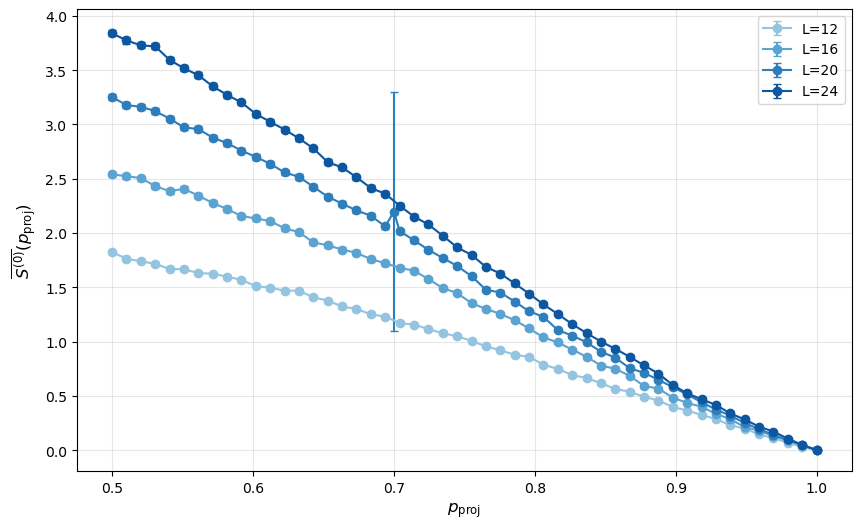

In [37]:
import matplotlib.pyplot as plt
# Plot estimator vs p for different L with same color scheme as data_collapse.py
fig, ax = plt.subplots(figsize=(10, 6))

L_list = df.index.get_level_values('L').unique().sort_values().values
color_iter = iter(plt.cm.Blues(0.4+0.6*(i/L_list.shape[0])) for i in range(L_list.shape[0]))

for L in L_list:
    color = next(color_iter)
    df_L = df.xs(key=L, level='L').sort_index()  # Add sort_index() here
    p_values = df_L.index.get_level_values('p').values
    estimator_values = df_L['estimator'].values
    stderr_values = df_L['standard_error'].values
    
    ax.errorbar(p_values, estimator_values, yerr=stderr_values, 
                fmt='o-', color=color, label=f'L={L}', capsize=3, markersize=6)

ax.set_xlabel(r'$p_{\mathrm{proj}}$', fontsize=12)
ax.set_ylabel(r'$\overline{S^{(0)}}(p_{\mathrm{proj}})$', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
# ax.set_ylim()
# plt.tight_layout()
plt.show()

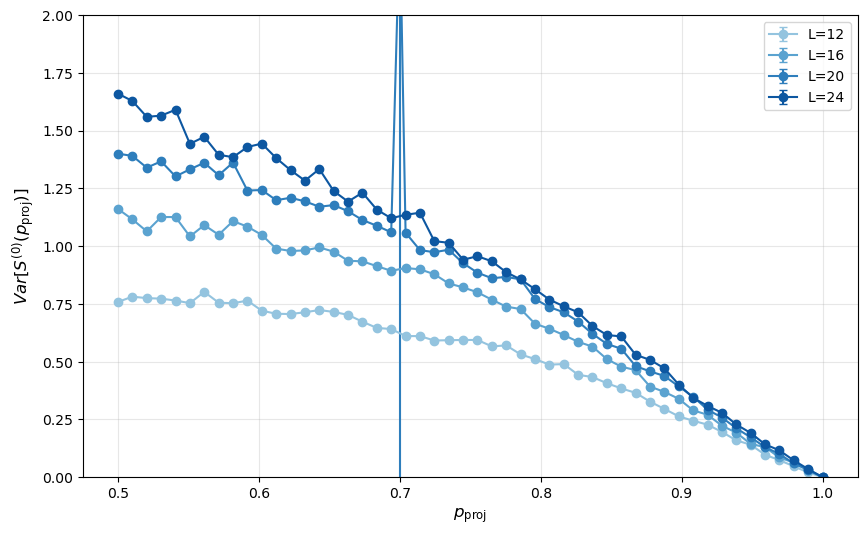

In [43]:
import matplotlib.pyplot as plt
# Plot estimator vs p for different L with same color scheme as data_collapse.py
fig, ax = plt.subplots(figsize=(10, 6))

L_list = df.index.get_level_values('L').unique().sort_values().values
color_iter = iter(plt.cm.Blues(0.4+0.6*(i/L_list.shape[0])) for i in range(L_list.shape[0]))

for L in L_list:
    color = next(color_iter)
    df_L = df.xs(key=L, level='L').sort_index()  # Add sort_index() here
    p_values = df_L.index.get_level_values('p').values
    estimator_values = df_L['variance'].values
    stderr_values = df_L['standard_error_of_variance'].values
    
    ax.errorbar(p_values, estimator_values, yerr=stderr_values, 
                fmt='o-', color=color, label=f'L={L}', capsize=3, markersize=6)

ax.set_xlabel(r'$p_{\mathrm{proj}}$', fontsize=12)
ax.set_ylabel(r'$Var[S^{(0)}(p_{\mathrm{proj}})]$', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 2)
# plt.tight_layout()
plt.show()

In [44]:
df.to_csv('MPS_0.4_cutoff1e-10_threshold1e-14.csv')

In [7]:
filename = "hdf5_data/p_ctrl0.4_haining/MPS_L24_pctrl0.400_pproj0.837_s1644.h5"
import h5py
files = os.listdir("hdf5_data/p_ctrl0.4_haining/")
print(files[:20])

['MPS_L30_pctrl0.400_pproj0.663_s268.h5', 'MPS_L24_pctrl0.400_pproj0.520_s529.h5', 'MPS_L24_pctrl0.400_pproj0.765_s856.h5', 'MPS_L24_pctrl0.400_pproj0.633_s1955.h5', 'MPS_L24_pctrl0.400_pproj0.714_s29.h5', 'MPS_L24_pctrl0.400_pproj0.857_s934.h5', 'MPS_L24_pctrl0.400_pproj0.724_s1620.h5', 'MPS_L24_pctrl0.400_pproj0.724_s1051.h5', 'MPS_L24_pctrl0.400_pproj0.633_s167.h5', 'MPS_L24_pctrl0.400_pproj0.949_s827.h5', 'MPS_L24_pctrl0.400_pproj0.918_s506.h5', 'MPS_L24_pctrl0.400_pproj0.867_s1520.h5', 'MPS_L24_pctrl0.400_pproj0.816_s126.h5', 'MPS_L24_pctrl0.400_pproj0.622_s922.h5', 'MPS_L24_pctrl0.400_pproj0.500_s1855.h5', 'MPS_L24_pctrl0.400_pproj0.847_s750.h5', 'MPS_L24_pctrl0.400_pproj0.939_s1053.h5', 'MPS_L24_pctrl0.400_pproj0.582_s1876.h5', 'MPS_L24_pctrl0.400_pproj0.643_s46.h5', 'MPS_L24_pctrl0.400_pproj0.929_s1134.h5']


In [34]:
import matplotlib.pyplot as plt
data_dict = {}
for filename in files[:10000]:
    full_path = os.path.join("hdf5_data/p_ctrl0.4_haining/", filename)
    with h5py.File(full_path, "r") as f:
        L, p_proj = f['sv_arr'].attrs['L'], f['sv_arr'].attrs['p_proj']
        sv_arr = f['sv_arr'][:]
        if (L, p_proj) not in data_dict:
            data_dict[(L, p_proj)] = [sv_arr]
        else:
            data_dict[(L, p_proj)].append(sv_arr)
print(len(data_dict))

51


(30, 0.6632653061224489) 1


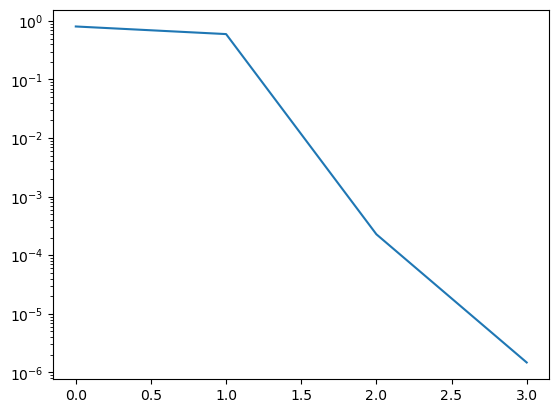

(24, 0.5204081632653061) 204


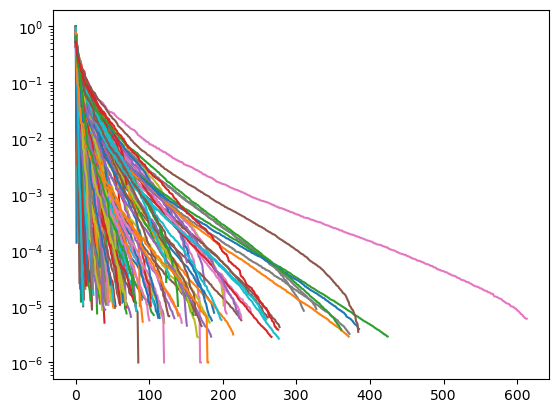

(24, 0.7653061224489796) 205


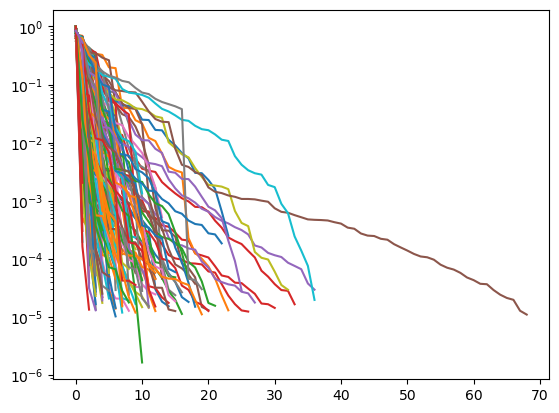

(24, 0.6326530612244898) 184


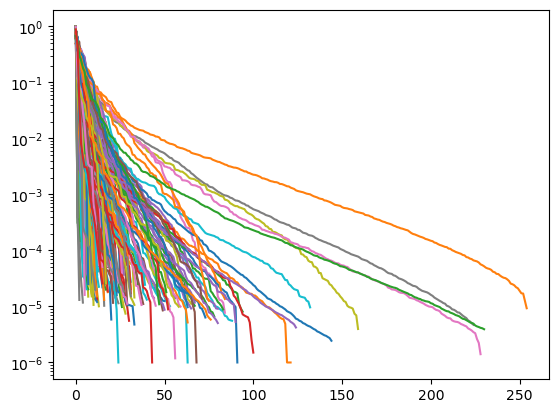

(24, 0.7142857142857143) 194


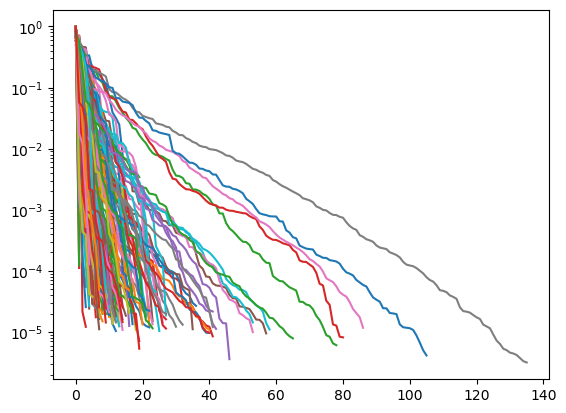

(24, 0.8571428571428571) 202


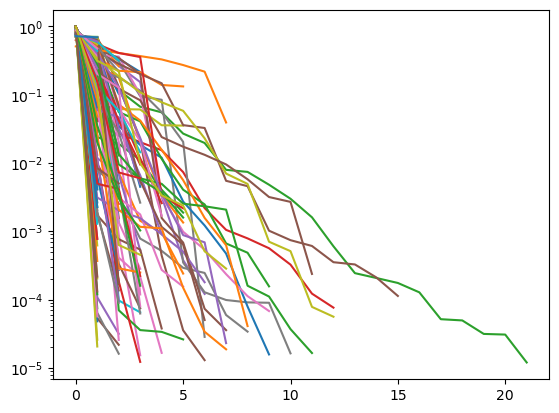

(24, 0.7244897959183674) 220


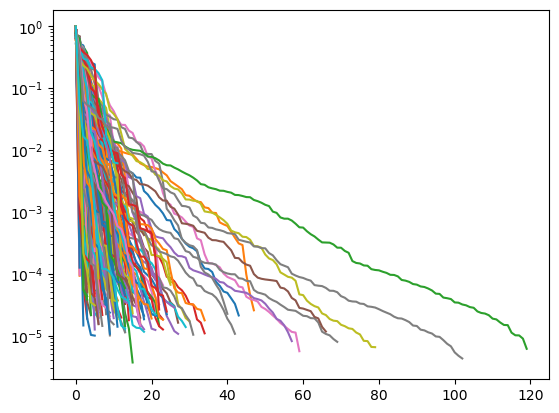

(24, 0.9489795918367346) 213


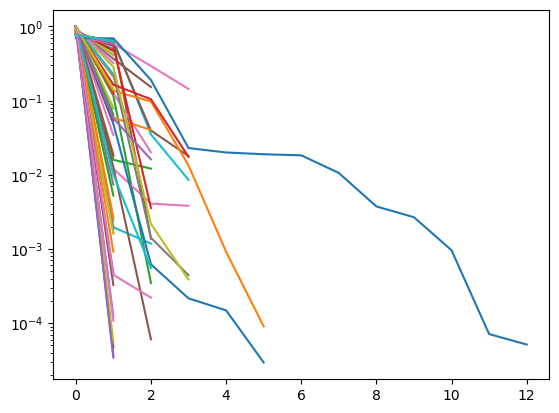

(24, 0.9183673469387754) 195


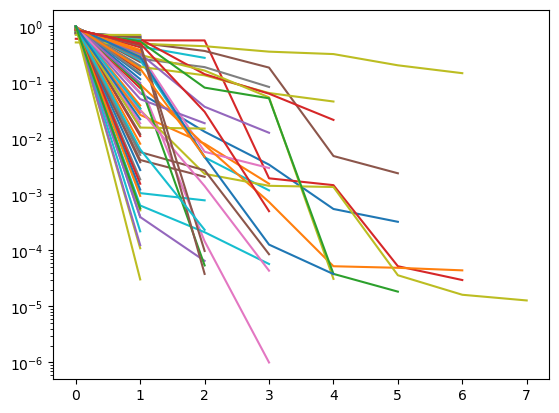

(24, 0.8673469387755102) 198


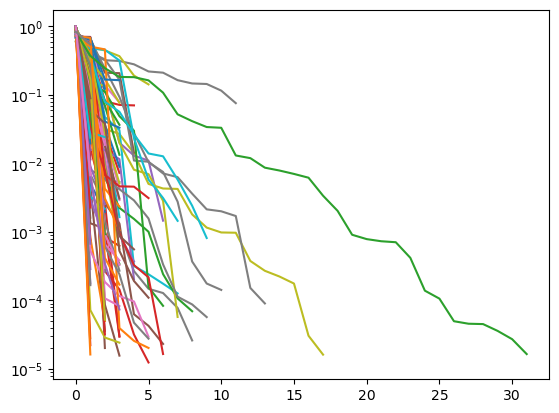

(24, 0.8163265306122449) 184


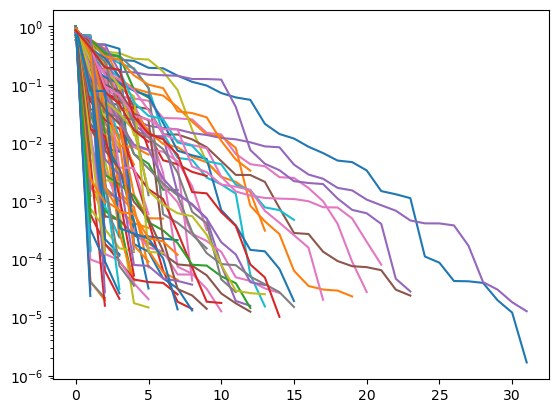

(24, 0.6224489795918368) 198


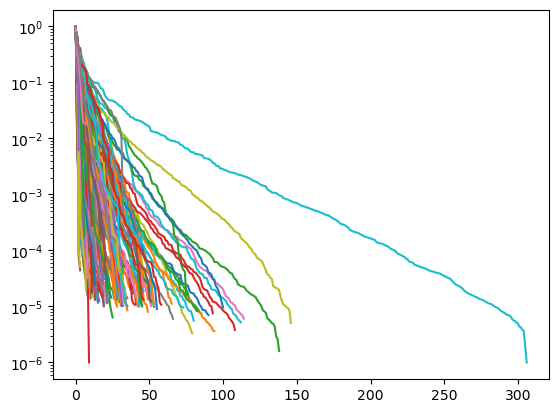

(24, 0.5) 207


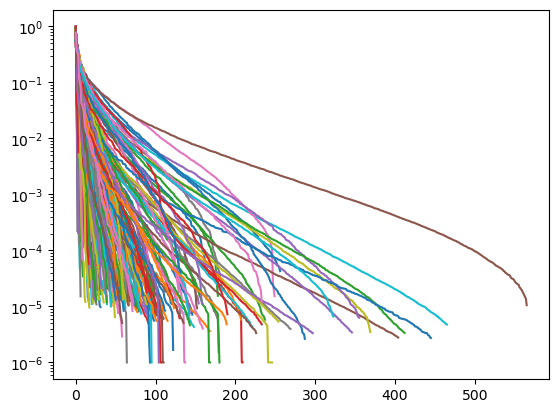

(24, 0.846938775510204) 203


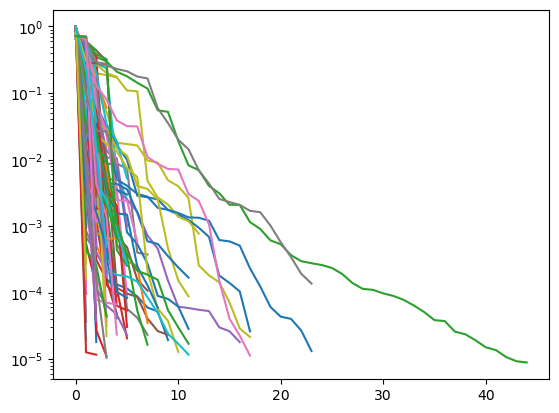

(24, 0.9387755102040816) 188


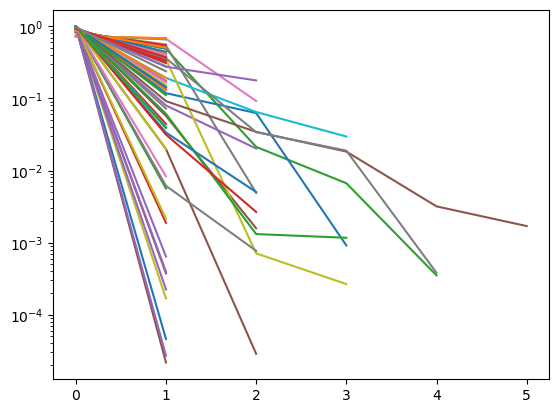

(24, 0.5816326530612245) 222


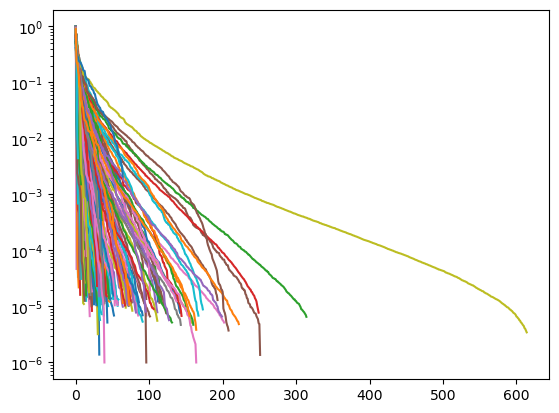

(24, 0.6428571428571428) 213


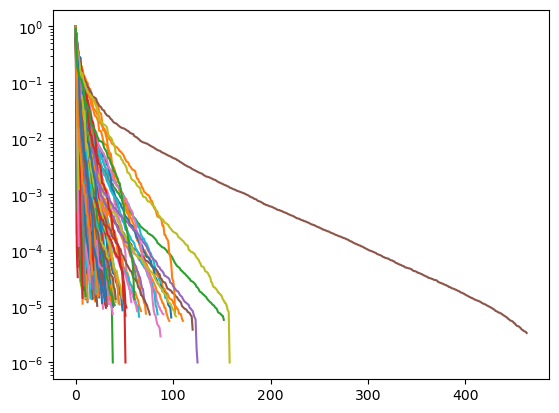

(24, 0.9285714285714286) 186


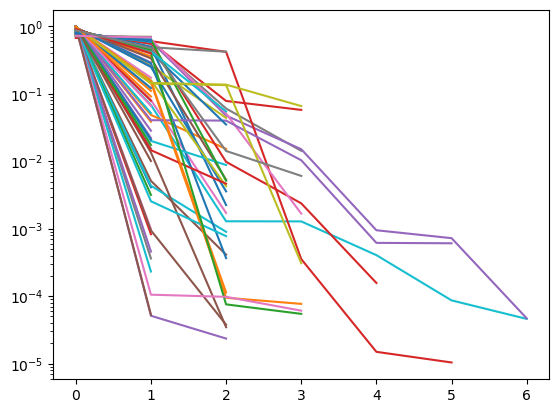

(24, 0.9897959183673469) 186


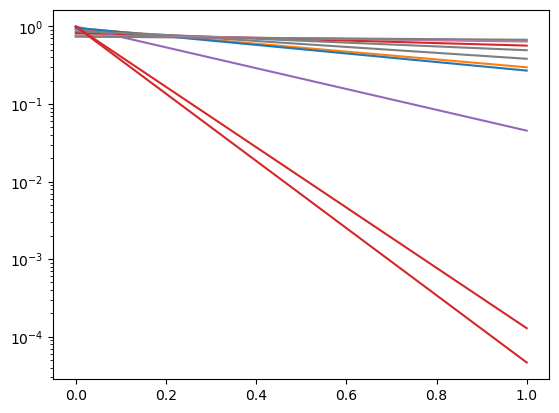

(24, 0.8367346938775511) 187


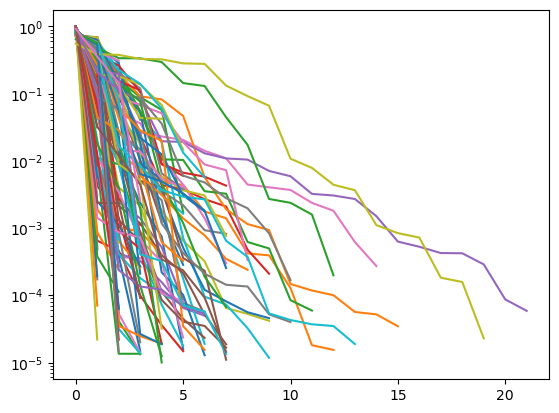

(24, 0.8775510204081632) 180


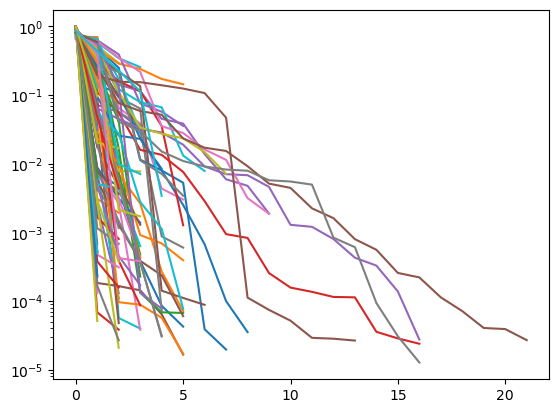

(24, 0.5102040816326531) 200


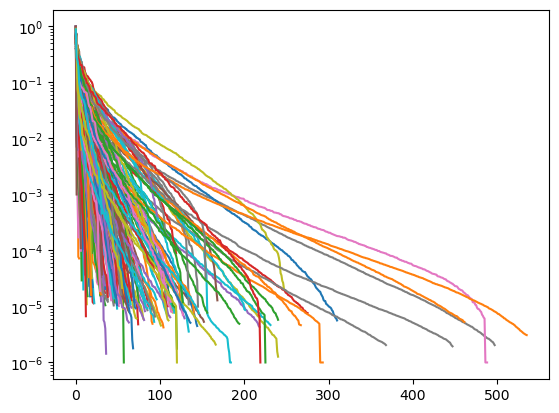

(24, 0.9081632653061225) 206


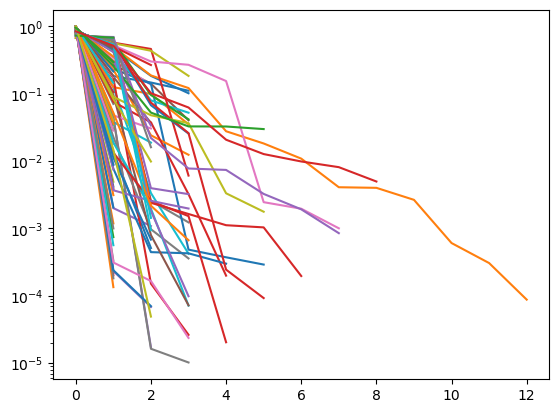

(24, 0.5510204081632653) 210


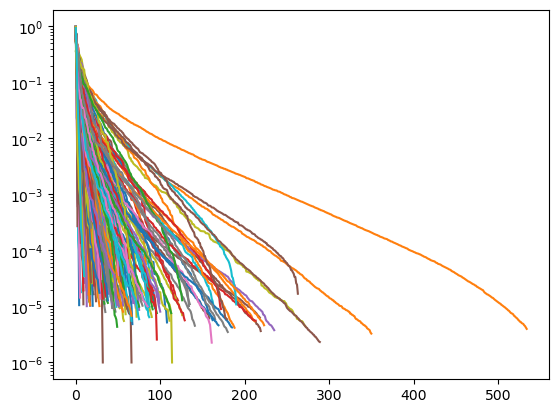

(24, 0.9795918367346939) 220


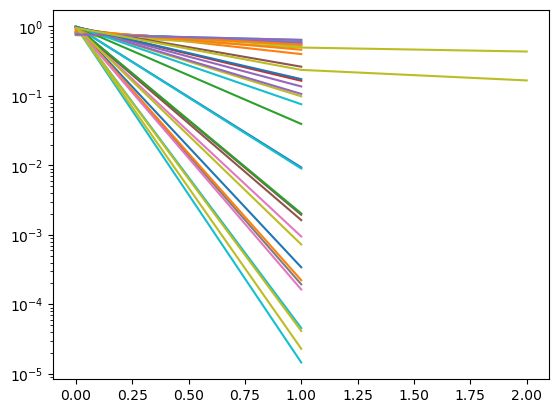

(24, 0.6938775510204082) 188


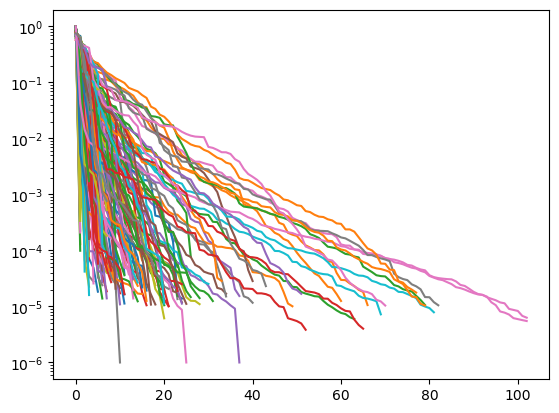

(24, 0.7755102040816326) 202


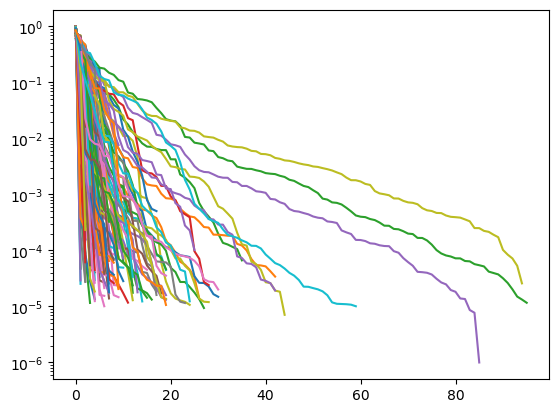

(24, 0.6122448979591837) 209


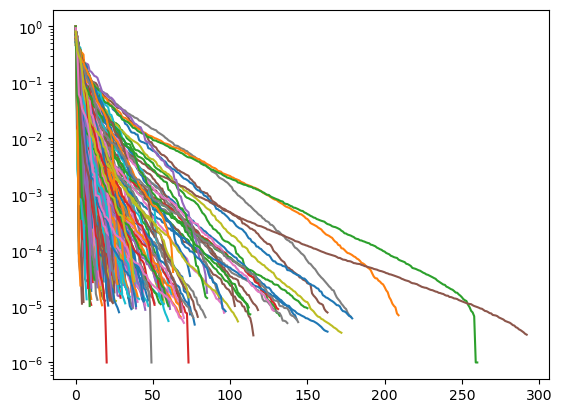

(24, 0.7959183673469388) 200


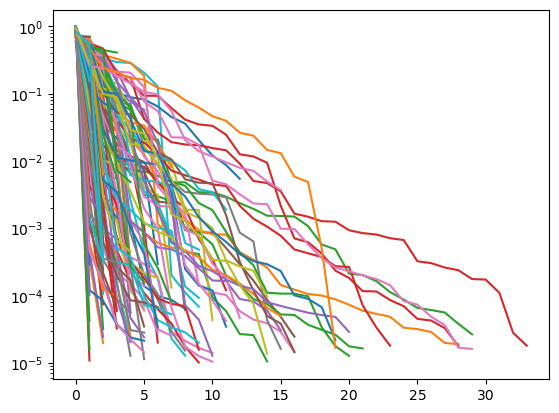

(24, 0.673469387755102) 199


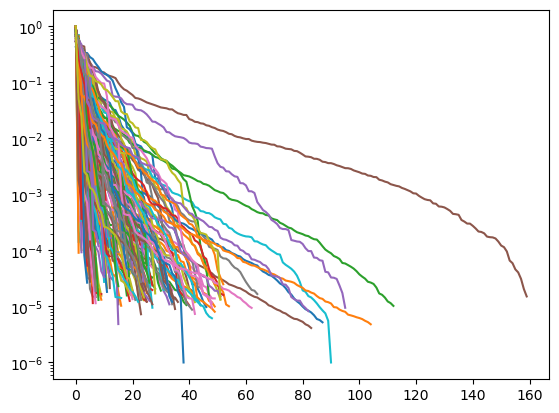

(24, 0.6632653061224489) 187


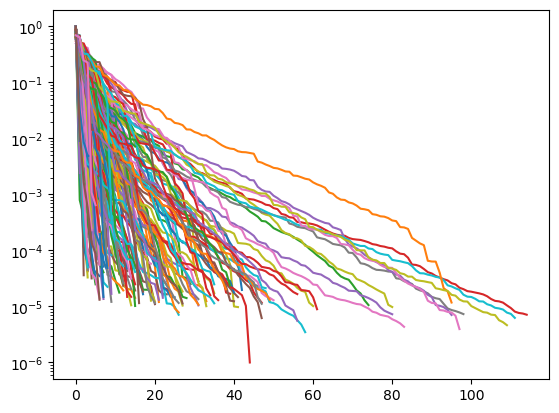

(24, 0.5408163265306123) 199


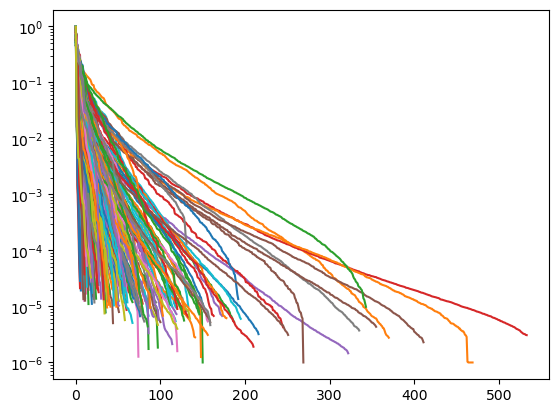

(24, 0.7346938775510203) 200


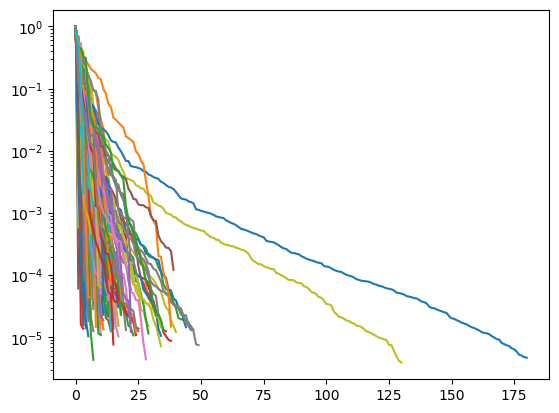

(24, 0.5918367346938775) 196


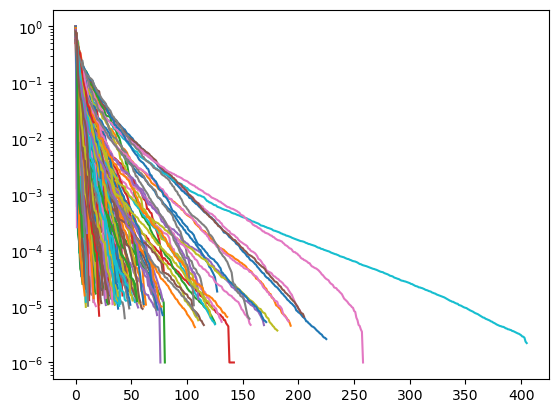

(24, 0.8061224489795917) 217


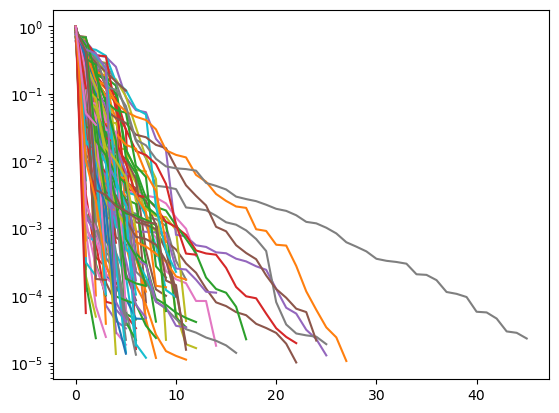

(24, 0.5612244897959183) 216


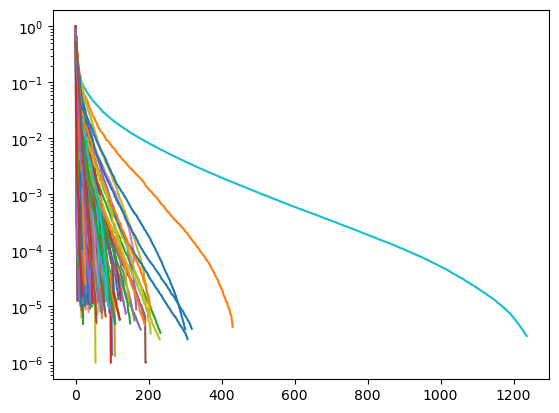

(24, 0.8265306122448979) 205


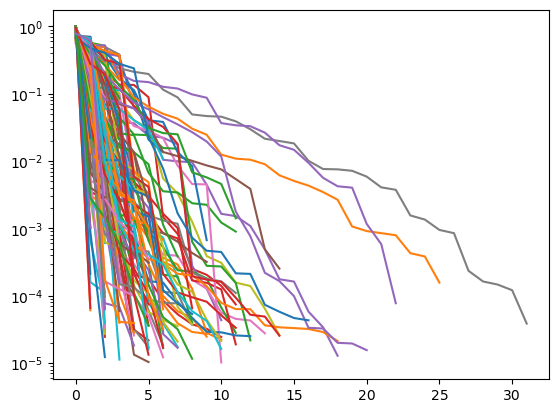

(24, 0.9591836734693877) 196


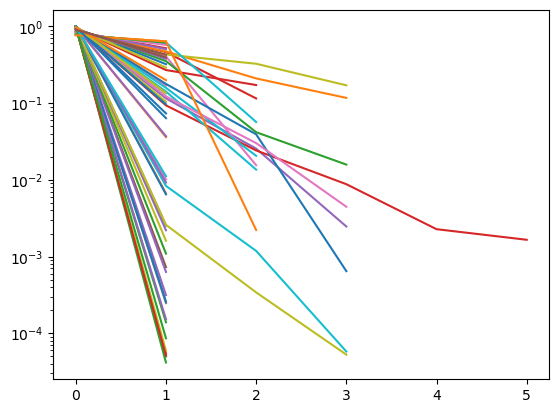

(24, 0.6530612244897959) 200


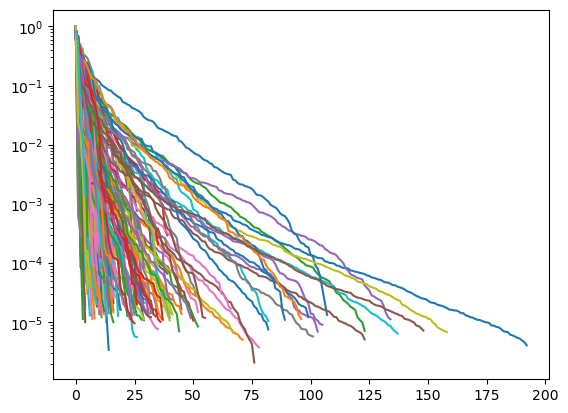

(24, 0.6020408163265306) 199


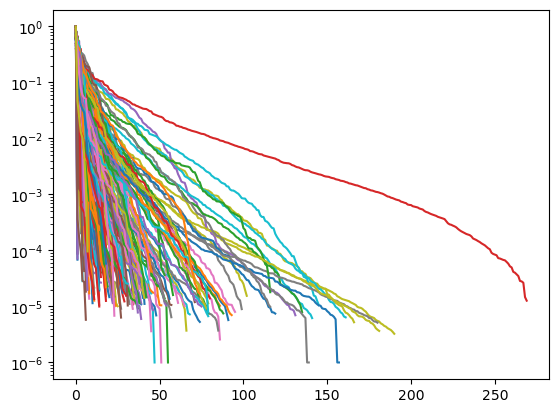

(24, 0.8979591836734693) 193


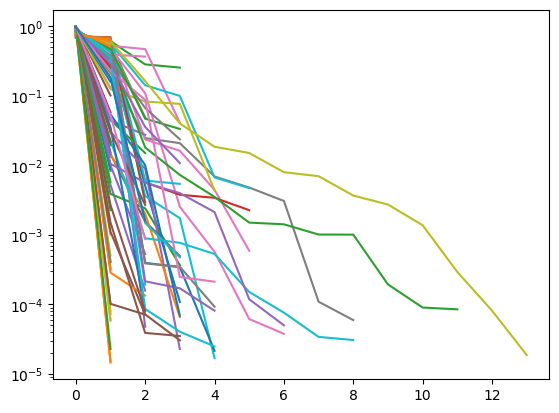

(24, 0.7040816326530612) 191


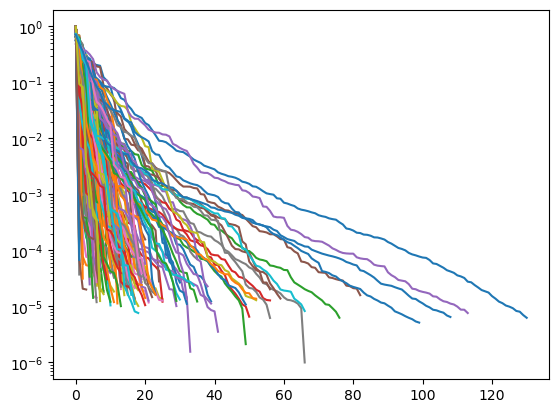

(24, 0.7857142857142857) 209


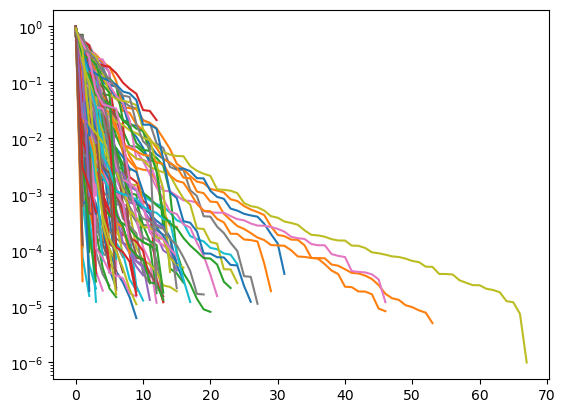

(24, 0.5306122448979592) 177


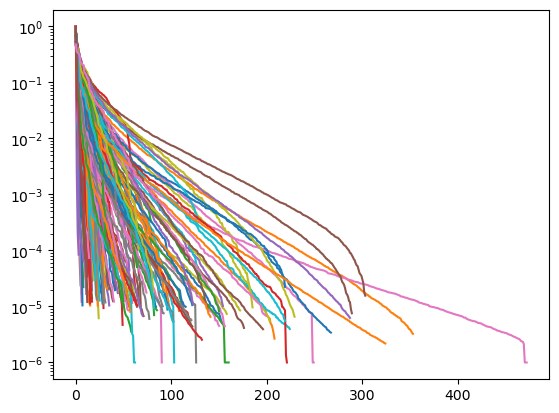

(24, 0.7551020408163265) 188


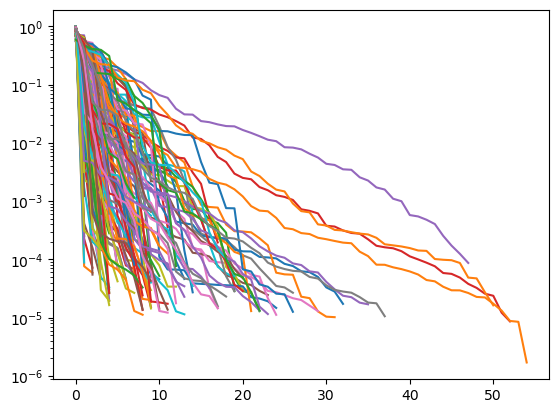

(24, 0.7448979591836735) 198


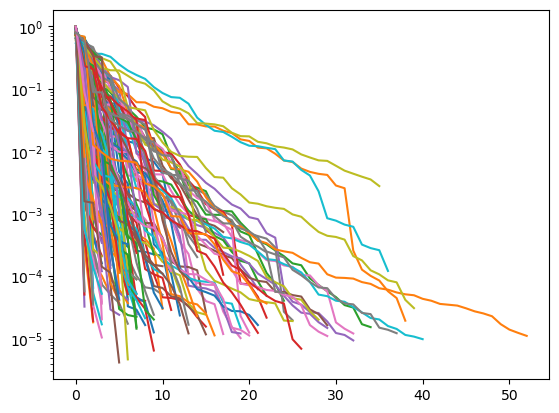

(24, 0.5714285714285714) 207


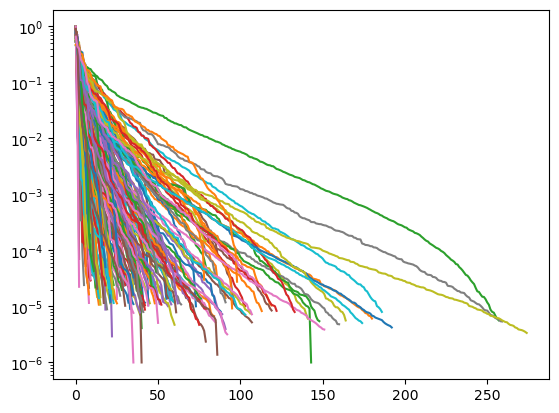

(24, 1.0) 222


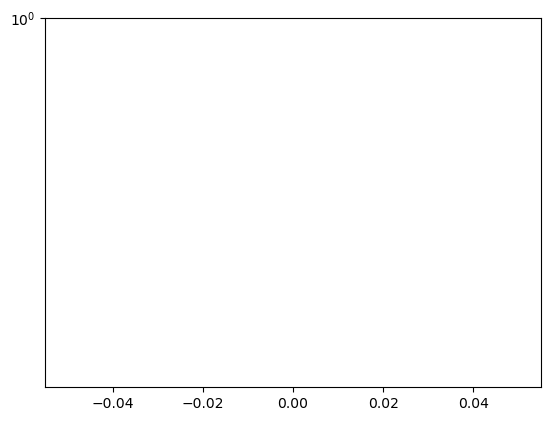

(24, 0.8877551020408163) 195


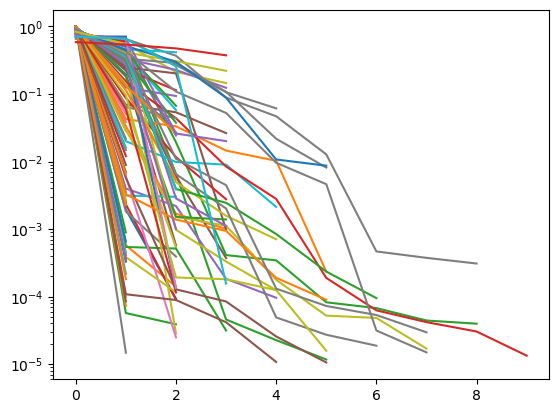

(24, 0.6836734693877551) 211


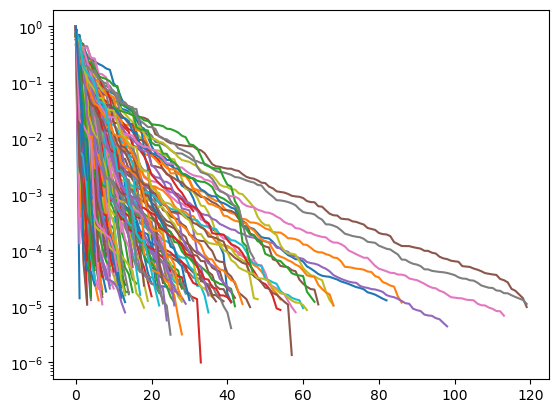

(24, 0.9693877551020408) 190


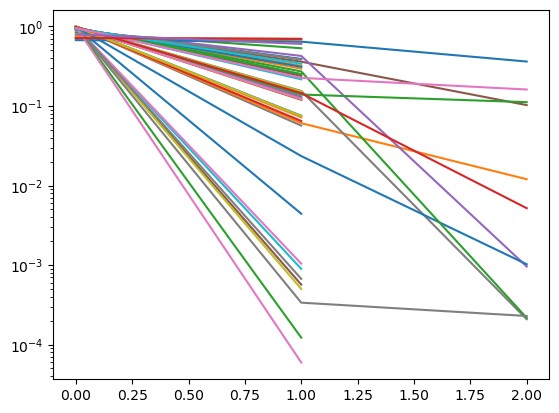

In [42]:
for key in data_dict.keys():
    print(key, len(data_dict[key]))
    for sv_arr in data_dict[key]:
        sv_arr = np.clip(sv_arr, 1e-6, 1.)
        plt.plot(sv_arr)
    plt.yscale('log')
    plt.show()



In [17]:
general_lst = []
lst = [2,4,2,34,24,4]
lst2 = [1234,345,64,57,234]
general_lst.append(lst)
general_lst.append(lst2)
max_len = max(len(sublist) for sublist in general_lst)
padded_general_lst = [sublist + [0]*(max_len - len(sublist)) for sublist in general_lst]
padded_general_lst


[[2, 4, 2, 34, 24, 4], [1234, 345, 64, 57, 234, 0]]

In [33]:
data_dict[(24, 0.673469387755102)]

[array([6.59183521e-01, 6.17313008e-01, 4.00100594e-01, 1.38113608e-01,
        4.96439304e-02, 3.95124957e-02, 2.80084481e-02, 1.79216903e-02,
        7.50143722e-03, 5.78922186e-03, 3.17815348e-03, 2.33519440e-03,
        2.20452183e-03, 1.42658236e-03, 1.04342379e-03, 7.31979624e-04,
        5.17635046e-04, 4.40462976e-04, 2.75356848e-04, 1.72459679e-04,
        1.53536978e-04, 8.96589139e-05, 4.95228055e-05, 4.19369450e-05,
        3.54505206e-05, 2.28212598e-05]),
 array([7.22826863e-01, 4.97118303e-01, 3.83245320e-01, 2.63573872e-01,
        1.04602762e-01, 4.82085362e-02, 2.04801108e-02, 1.40910605e-02,
        9.19766325e-03, 4.26276135e-03, 4.21821109e-03, 3.56113029e-03,
        2.91157146e-03, 2.45034974e-03, 2.05987996e-03, 1.85794678e-03,
        1.41727352e-03, 1.28415946e-03, 8.89130039e-04, 8.35240884e-04,
        7.09831114e-04, 6.30856653e-04, 6.10888230e-04, 4.89906563e-04,
        4.34035964e-04, 3.83803839e-04, 3.64510524e-04, 2.50709772e-04,
        2.00621674e-04